# Feature Diagnostics Figures

Generates poster-ready figures from `outputs_restart/` using the project color palette:
- `#F5C518` (yellow)
- `#000000` / `#FFFFFF`
- `#1848f5` (blue accents)


In [10]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BASE = Path('/home/djameldino/Big-Data/big_data_assignment/members/djamel/outputs_restart')
FIG_DIR = BASE / 'notebook_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

YELLOW = '#F5C518'
BLUE = '#1848f5'
BLACK = '#000000'
CARD = '#111111'
WHITE = '#FFFFFF'
MUTED = '#CFCFCF'

print('Base:', BASE)
print('Figure dir:', FIG_DIR)


Base: /home/djameldino/Big-Data/big_data_assignment/members/djamel/outputs_restart
Figure dir: /home/djameldino/Big-Data/big_data_assignment/members/djamel/outputs_restart/notebook_figures


## Explicit DuckDB Step (JSON -> many-to-many)

This diagnostics phase still depends on the **DuckDB normalization step** from the pipeline:
- `directing.json` is exploded into `(tconst, director_id)` edges with DuckDB SQL (`json_each`).
- `writing.json` is loaded into `(tconst, writer_id)` edges with DuckDB.

The cell below explicitly runs DuckDB on raw JSON and reports edge counts.

In [11]:
import duckdb

PROJECT_ROOT = Path('/home/djameldino/Big-Data/big_data_assignment')
raw_json_dir = PROJECT_ROOT / 'data' / 'raw' / 'json'
directing_json = raw_json_dir / 'directing.json'
writing_json = raw_json_dir / 'writing.json'

con = duckdb.connect()
duckdb_directing_edges = con.execute(
    """
    WITH src AS (
      SELECT json(movie) AS movie_obj, json(director) AS director_obj
      FROM read_json_auto(?)
    ),
    movies AS (
      SELECT je.key AS k, trim(both '\"' from CAST(je.value AS VARCHAR)) AS tconst
      FROM src, json_each(movie_obj) je
    ),
    directors AS (
      SELECT je.key AS k, trim(both '\"' from CAST(je.value AS VARCHAR)) AS director_id
      FROM src, json_each(director_obj) je
    )
    SELECT COUNT(*)
    FROM movies m
    JOIN directors d USING (k)
    """,
    [str(directing_json)],
).fetchone()[0]

duckdb_writing_edges = con.execute(
    "SELECT COUNT(*) FROM read_json_auto(?)",
    [str(writing_json)],
).fetchone()[0]

duckdb_directing_sample = con.execute(
    """
    WITH src AS (
      SELECT json(movie) AS movie_obj, json(director) AS director_obj
      FROM read_json_auto(?)
    ),
    movies AS (
      SELECT je.key AS k, trim(both '\"' from CAST(je.value AS VARCHAR)) AS tconst
      FROM src, json_each(movie_obj) je
    ),
    directors AS (
      SELECT je.key AS k, trim(both '\"' from CAST(je.value AS VARCHAR)) AS director_id
      FROM src, json_each(director_obj) je
    )
    SELECT m.tconst, d.director_id
    FROM movies m
    JOIN directors d USING (k)
    LIMIT 5
    """,
    [str(directing_json)],
).fetchdf()

print(f'DuckDB directing edges: {duckdb_directing_edges}')
print(f'DuckDB writing edges: {duckdb_writing_edges}')
duckdb_directing_sample


DuckDB directing edges: 11162
DuckDB writing edges: 22428


,tconst,director_id
0,tt9911196,nm0631590
1,tt9904802,nm0052054
2,tt9900782,nm7992231
3,tt9850386,nm0550881
4,tt9850344,nm0284774


In [12]:
xgb_imp = pd.read_csv(BASE / 'xgb_feature_importance.csv')
goodness = pd.read_csv(BASE / 'feature_goodness.csv')
diag = pd.read_csv(BASE / 'feature_diagnostics.csv')
timings = pd.read_csv(BASE / 'step_timings.csv')
metrics = json.loads((BASE / 'model_validation_metrics.json').read_text(encoding='utf-8'))
reduced_metrics = json.loads((BASE / 'reduced_model_validation_metrics.json').read_text(encoding='utf-8'))

print('xgb_imp:', xgb_imp.shape)
print('goodness:', goodness.shape)
print('diag:', diag.shape)
print('timings:', timings.shape)
print('metrics keys:', list(metrics.keys()))
print('reduced keys:', list(reduced_metrics.keys()))


xgb_imp: (30, 4)
goodness: (30, 12)
diag: (30, 17)
timings: (18, 2)
metrics keys: ['logistic_validation_accuracy', 'logistic_validation_roc_auc', 'train_rows', 'validation_rows', 'xgb_validation_accuracy', 'xgb_validation_roc_auc', 'best_model_for_hidden_predictions']
reduced keys: ['feature_count', 'validation_accuracy', 'validation_roc_auc', 'base_model', 'full_model_roc_auc', 'roc_auc_delta_vs_full']


In [13]:
def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_facecolor(CARD)
    ax.set_title(title, color=WHITE, fontsize=14, fontweight='bold')
    if xlabel:
        ax.set_xlabel(xlabel, color=WHITE)
    if ylabel:
        ax.set_ylabel(ylabel, color=WHITE)
    ax.tick_params(axis='x', colors=WHITE)
    ax.tick_params(axis='y', colors=WHITE)
    for spine in ax.spines.values():
        spine.set_color(MUTED)

plt.rcParams['figure.facecolor'] = BLACK
plt.rcParams['axes.facecolor'] = CARD
plt.rcParams['savefig.facecolor'] = BLACK


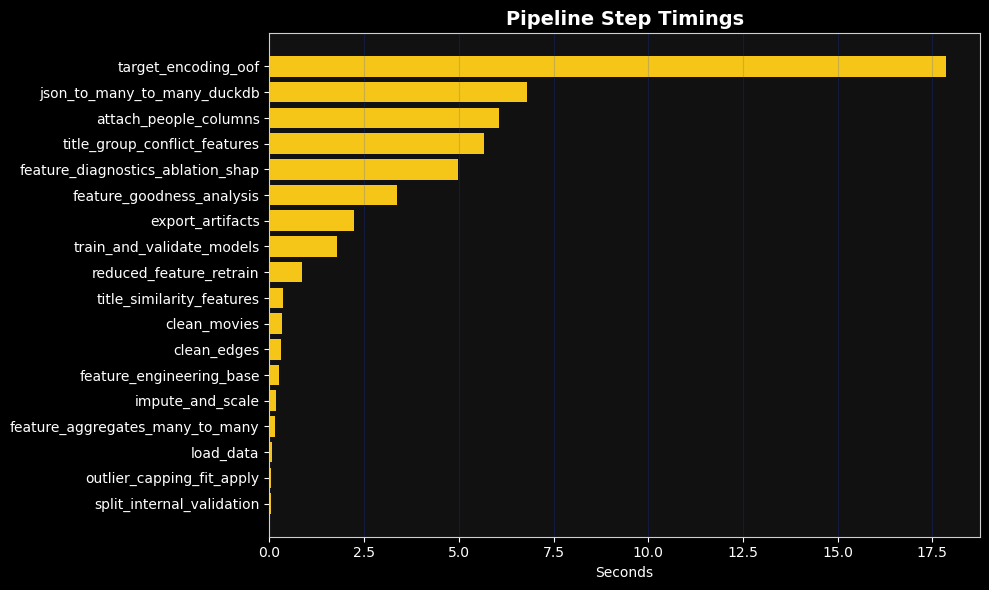

In [14]:
# 1) Pipeline step timings
plot_df = timings.sort_values('seconds', ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['step'], plot_df['seconds'], color=YELLOW)
style_ax(ax, 'Pipeline Step Timings', xlabel='Seconds')
ax.grid(axis='x', alpha=0.20, color=BLUE)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_step_timings.png', dpi=180)
plt.show()
plt.close(fig)


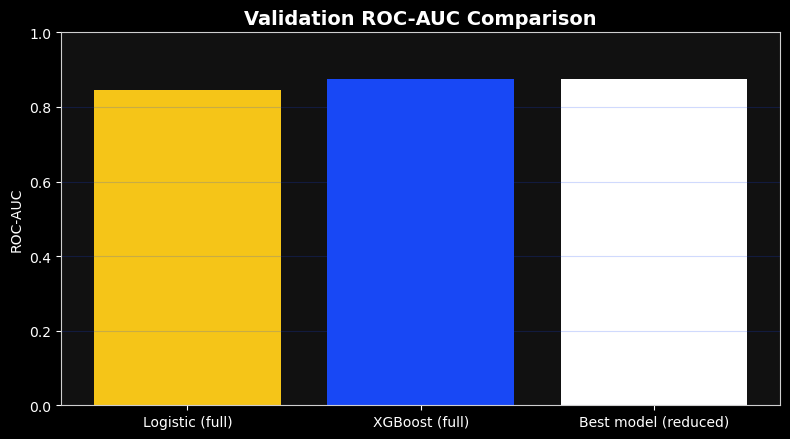

,model,roc_auc
0,Logistic (full),0.844040
1,XGBoost (full),0.875007
2,Best model (reduced),0.875428


In [15]:
# 2) Model ROC-AUC comparison (full + reduced)
model_auc_rows = [
    ('Logistic (full)', float(metrics['logistic_validation_roc_auc'])),
    ('XGBoost (full)', float(metrics['xgb_validation_roc_auc'])),
    ('Best model (reduced)', float(reduced_metrics['validation_roc_auc']))
]
auc_df = pd.DataFrame(model_auc_rows, columns=['model', 'roc_auc'])

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [YELLOW, BLUE, '#FFFFFF']
ax.bar(auc_df['model'], auc_df['roc_auc'], color=colors)
ax.set_ylim(0.0, 1.0)
style_ax(ax, 'Validation ROC-AUC Comparison', ylabel='ROC-AUC')
ax.grid(axis='y', alpha=0.20, color=BLUE)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_model_auc_comparison.png', dpi=180)
plt.show()
plt.close(fig)

display(auc_df)


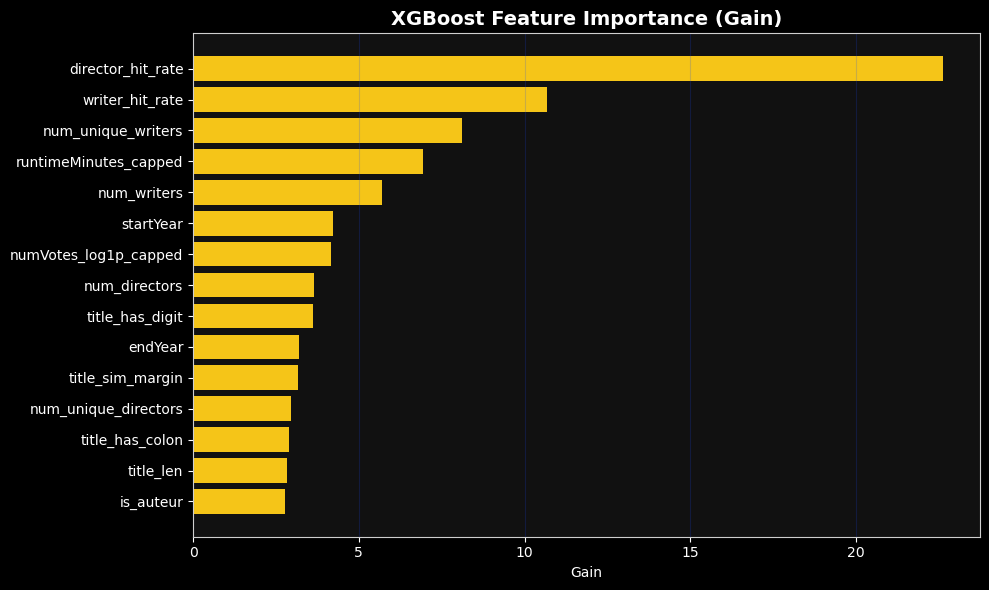

,feature,gain,weight,cover
0,director_hit_rate,22.613407,435.0,329.168243
1,writer_hit_rate,10.670019,709.0,246.674637
2,num_unique_writers,8.108745,72.0,260.732269
3,runtimeMinutes_capped,6.935695,1340.0,165.033920
4,num_writers,5.709679,429.0,183.343689
5,startYear,4.219222,1213.0,176.383408
6,numVotes_log1p_capped,4.158208,1467.0,179.668365
7,num_directors,3.646239,145.0,303.713684
8,title_has_digit,3.604116,70.0,341.120178
9,endYear,3.202257,267.0,344.879150


In [16]:
# 3) XGBoost feature importance
top_imp = xgb_imp.sort_values('gain', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_imp['feature'][::-1], top_imp['gain'][::-1], color=YELLOW)
style_ax(ax, 'XGBoost Feature Importance (Gain)', xlabel='Gain')
ax.grid(axis='x', alpha=0.20, color=BLUE)
fig.tight_layout()
fig.savefig(FIG_DIR / '03_xgb_feature_importance.png', dpi=180)
plt.show()
plt.close(fig)

display(top_imp)


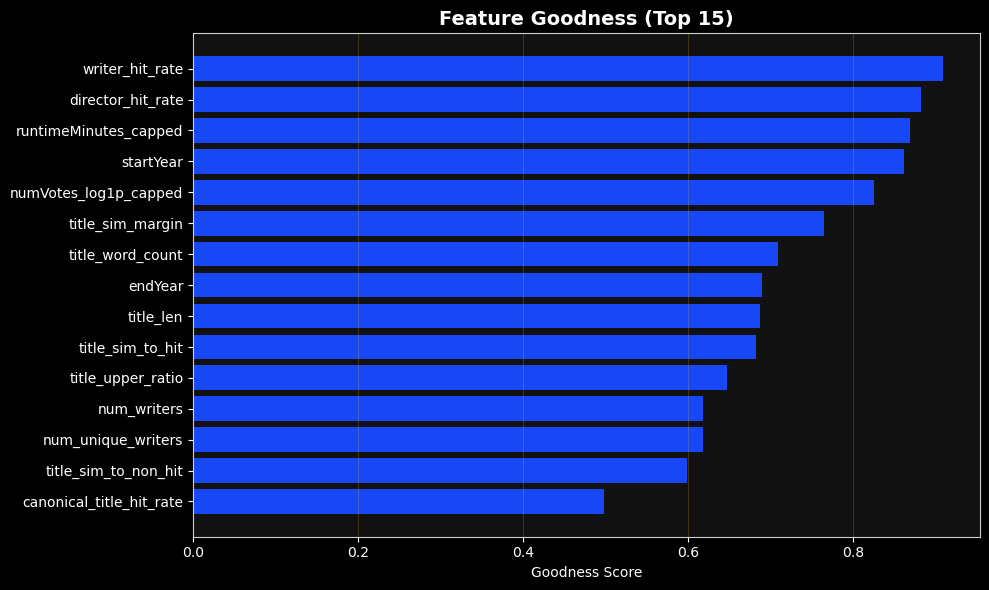

,feature,goodness_score,univariate_auc_val,mutual_info_train,psi_train_vs_val
0,writer_hit_rate,0.908333,0.736897,0.110964,0.009486
1,director_hit_rate,0.881667,0.736136,0.109526,0.020335
2,runtimeMinutes_capped,0.868333,0.710850,0.078190,0.007529
3,startYear,0.861667,0.620885,0.039887,0.001623
4,numVotes_log1p_capped,0.825000,0.599510,0.033343,0.003789
5,title_sim_margin,0.765000,0.586825,0.017994,0.028264
6,title_word_count,0.708333,0.536982,0.001976,0.006006
7,endYear,0.690000,0.521744,0.000008,0.000335
8,title_len,0.686667,0.532215,0.010725,0.013385
9,title_sim_to_hit,0.681667,0.522642,0.014747,0.012666


In [17]:
# 4) Feature goodness (model-agnostic)
top_good = goodness.sort_values('goodness_score', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_good['feature'][::-1], top_good['goodness_score'][::-1], color=BLUE)
style_ax(ax, 'Feature Goodness (Top 15)', xlabel='Goodness Score')
ax.grid(axis='x', alpha=0.20, color=YELLOW)
fig.tight_layout()
fig.savefig(FIG_DIR / '04_feature_goodness.png', dpi=180)
plt.show()
plt.close(fig)

display(top_good[['feature', 'goodness_score', 'univariate_auc_val', 'mutual_info_train', 'psi_train_vs_val']])


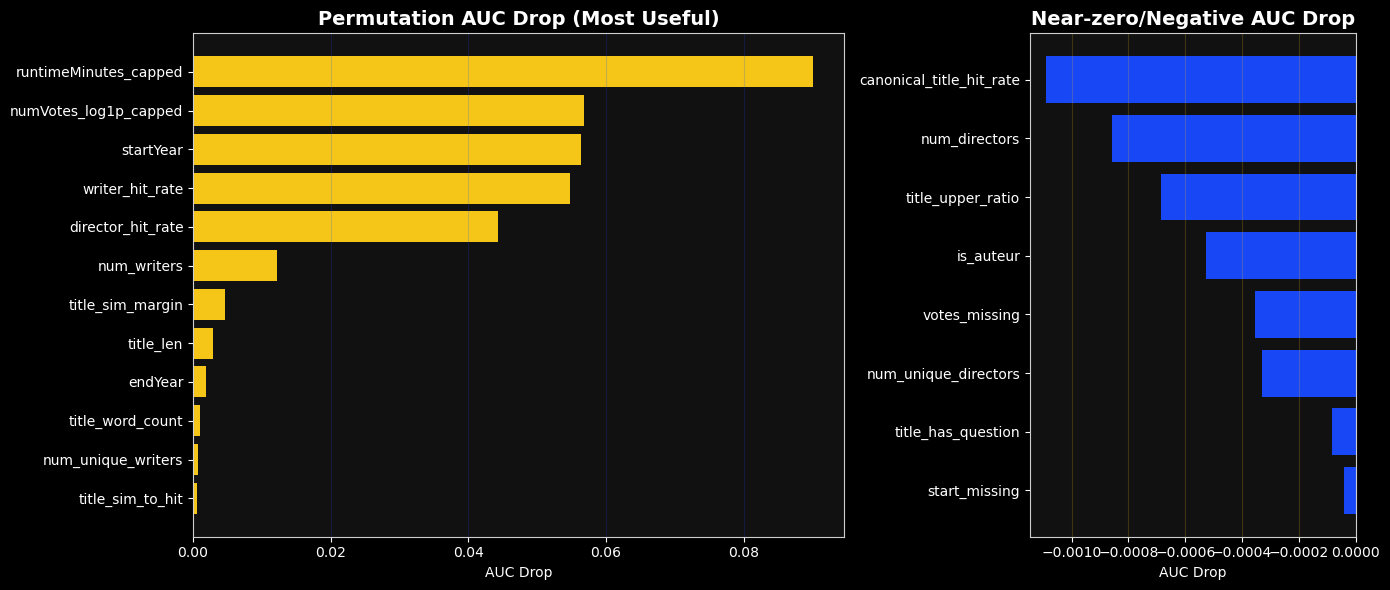

,feature,perm_auc_drop,status,diagnostic_score
13,runtimeMinutes_capped,0.090143,keep,0.951667
16,numVotes_log1p_capped,0.056868,keep,0.891667
15,startYear,0.056391,keep,0.901667
12,writer_hit_rate,0.054836,keep,0.960000
14,director_hit_rate,0.044317,keep,0.936667
19,num_writers,0.012227,keep,0.730000
17,title_sim_margin,0.004656,keep,0.796667
20,title_len,0.002888,keep,0.720000
18,endYear,0.001804,keep,0.745000
21,title_word_count,0.001042,keep,0.690000


In [18]:
# 5) Permutation AUC-drop (best model)
diag_sorted = diag.sort_values('perm_auc_drop', ascending=False)
top_pos = diag_sorted.head(12)
top_neg = diag_sorted.tail(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

axes[0].barh(top_pos['feature'][::-1], top_pos['perm_auc_drop'][::-1], color=YELLOW)
style_ax(axes[0], 'Permutation AUC Drop (Most Useful)', xlabel='AUC Drop')
axes[0].grid(axis='x', alpha=0.20, color=BLUE)

axes[1].barh(top_neg['feature'], top_neg['perm_auc_drop'], color=BLUE)
style_ax(axes[1], 'Near-zero/Negative AUC Drop', xlabel='AUC Drop')
axes[1].grid(axis='x', alpha=0.20, color=YELLOW)

fig.tight_layout()
fig.savefig(FIG_DIR / '05_permutation_auc_drop.png', dpi=180)
plt.show()
plt.close(fig)

display(diag[['feature', 'perm_auc_drop', 'status', 'diagnostic_score']].sort_values('perm_auc_drop', ascending=False).head(25))


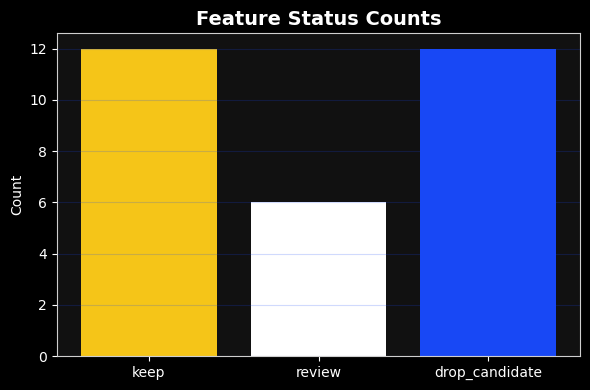

KEEP features:


,feature,diagnostic_score,perm_auc_drop,goodness_score,xgb_gain,mean_abs_shap
12,writer_hit_rate,0.960000,0.054836,0.908333,10.670019,0.553842
13,runtimeMinutes_capped,0.951667,0.090143,0.868333,6.935695,0.722430
14,director_hit_rate,0.936667,0.044317,0.881667,22.613407,0.529598
15,startYear,0.901667,0.056391,0.861667,4.219222,0.539057
16,numVotes_log1p_capped,0.891667,0.056868,0.825000,4.158208,0.577583
17,title_sim_margin,0.796667,0.004656,0.765000,3.155401,0.189714
18,endYear,0.745000,0.001804,0.690000,3.202257,0.051706
19,num_writers,0.730000,0.012227,0.618333,5.709679,0.170284
20,title_len,0.720000,0.002888,0.686667,2.842881,0.160894
21,title_word_count,0.690000,0.001042,0.708333,2.231136,0.063346


DROP candidates:


,feature,diagnostic_score,perm_auc_drop,goodness_score,xgb_gain,mean_abs_shap
10,title_conflicting_years,0.125000,0.000000,0.169167,0.000000,0.000000
11,year_span,0.125000,0.000000,0.169167,0.000000,0.000000
9,runtime_missing,0.150000,0.000000,0.196667,0.000000,0.000000
8,votes_missing,0.210833,-0.000354,0.251667,2.150927,0.008511
7,title_has_question,0.212500,-0.000084,0.253333,1.497408,0.003246
6,title_unique_years_train,0.214167,-0.000019,0.221667,2.406932,0.019455
5,title_group_size_train,0.250833,0.000000,0.295000,1.818260,0.000474
4,end_missing,0.258333,0.000000,0.334167,0.000000,0.000000
3,start_missing,0.280833,-0.000043,0.334167,2.138041,0.003043
2,num_unique_directors,0.407500,-0.000330,0.445833,2.943541,0.006915


In [19]:
# 6) Keep vs drop candidate tables
keep_df = diag[diag['status'] == 'keep'][['feature', 'diagnostic_score', 'perm_auc_drop', 'goodness_score', 'xgb_gain', 'mean_abs_shap']].sort_values('diagnostic_score', ascending=False)
drop_df = diag[diag['status'] == 'drop_candidate'][['feature', 'diagnostic_score', 'perm_auc_drop', 'goodness_score', 'xgb_gain', 'mean_abs_shap']].sort_values(['diagnostic_score', 'perm_auc_drop'])

fig, ax = plt.subplots(figsize=(6, 4))
counts = diag['status'].value_counts()
order = ['keep', 'review', 'drop_candidate']
vals = [int(counts.get(k, 0)) for k in order]
ax.bar(order, vals, color=[YELLOW, '#FFFFFF', BLUE])
style_ax(ax, 'Feature Status Counts', ylabel='Count')
ax.grid(axis='y', alpha=0.20, color=BLUE)
fig.tight_layout()
fig.savefig(FIG_DIR / '06_feature_status_counts.png', dpi=180)
plt.show()
plt.close(fig)

print('KEEP features:')
display(keep_df)
print('DROP candidates:')
display(drop_df)
